{'Created': 476, 'First Response': np.int64(366), 'In Progress': np.int64(0), 'Resolved': np.int64(12), 'Closed': np.int64(468)}
             From              To  Users Lost  Completion %   Drop %
0         Created  First Response         110         76.89    23.11
1  First Response     In Progress         366          0.00   100.00
2     In Progress        Resolved         -12          0.00     0.00
3        Resolved          Closed        -456       3900.00 -3800.00

Biggest Bottleneck

From            First Response
To                 In Progress
Users Lost                 366
Completion %               0.0
Drop %                   100.0
Name: 1, dtype: object


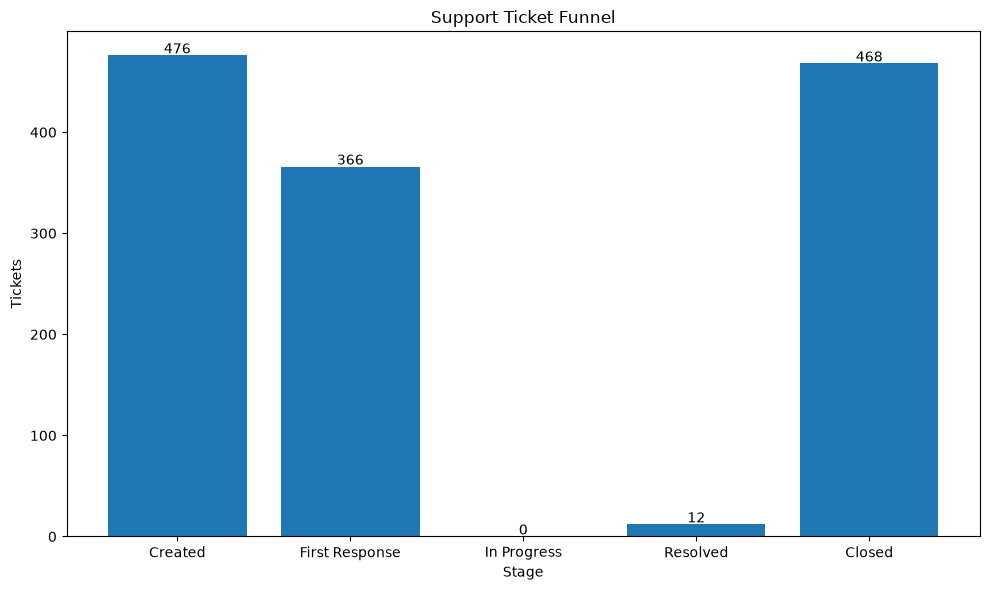

                     Drop Point  Tickets Lost  Revenue Impact ($) Priority
0      Created → First Response           110               11000   MEDIUM
1  First Response → In Progress           366               36600   MEDIUM
2        In Progress → Resolved           -12               -1200   MEDIUM
3             Resolved → Closed          -456              -45600   MEDIUM


FUNNEL ANALYSIS REPORT


Highest Bottleneck

First Response → In Progress

Tickets Lost : 366

Drop Rate : 100.0%

Estimated Revenue Impact : $36,600

Recommendations

1 Improve response time

2 Reduce resolution delay

3 Automate notifications

4 Escalate long pending tickets

5 Track SLA compliance

Expected Improvement

Recovering only 10% of lost tickets gives

Additional Tickets : 36

Estimated Revenue : $3,660



Saved
../output/funnel_chart.png
../output/funnel_analysis.txt


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------
# Load Data
# ---------------------------------------------------

df = pd.read_excel(
    "../data/processed/Combined_Data.xlsx",
    sheet_name="Support Tickets"
)

# ---------------------------------------------------
# Convert Dates
# ---------------------------------------------------

df["Created Time (Ticket)"] = pd.to_datetime(
    df["Created Time (Ticket)"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df["First Response Time"] = pd.to_datetime(
    df["First Response Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df["Ticket Closed Time"] = pd.to_datetime(
    df["Ticket Closed Time"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

# ---------------------------------------------------
# Funnel Stage Counts
# ---------------------------------------------------

created = len(df)

responded = df["First Response Time"].notna().sum()

in_progress = (
    df["Status (Ticket)"]
    .astype(str)
    .str.contains("Progress", case=False, na=False)
).sum()

resolved = (
    df["Status (Ticket)"]
    .astype(str)
    .str.contains("Resolved", case=False, na=False)
).sum()

closed = df["Ticket Closed Time"].notna().sum()

stages = {
    "Created": created,
    "First Response": responded,
    "In Progress": in_progress,
    "Resolved": resolved,
    "Closed": closed
}

print(stages)

# ---------------------------------------------------
# Drop-off Analysis
# ---------------------------------------------------

stage_names = list(stages.keys())
stage_values = list(stages.values())

drop_data = []

for i in range(len(stage_values)-1):

    before = stage_values[i]
    after = stage_values[i+1]

    lost = before-after

    completion = (after/before)*100 if before else 0

    drop = (lost/before)*100 if before else 0

    drop_data.append({

        "From":stage_names[i],
        "To":stage_names[i+1],
        "Users Lost":lost,
        "Completion %":round(completion,2),
        "Drop %":round(drop,2)

    })

funnel_df = pd.DataFrame(drop_data)

print(funnel_df)

# ---------------------------------------------------
# Biggest Bottleneck
# ---------------------------------------------------

idx = funnel_df["Users Lost"].idxmax()

print("\nBiggest Bottleneck\n")

print(funnel_df.loc[idx])

# ---------------------------------------------------
# Funnel Chart
# ---------------------------------------------------

Path("../output").mkdir(exist_ok=True)

plt.figure(figsize=(10,6))

plt.bar(
    stages.keys(),
    stages.values()
)

plt.title("Support Ticket Funnel")

plt.xlabel("Stage")

plt.ylabel("Tickets")

for x,y in zip(stages.keys(),stages.values()):
    plt.text(x,y+2,str(y),ha="center")

plt.tight_layout()

plt.savefig("../output/funnel_chart.png")

plt.show()

# ---------------------------------------------------
# Business Impact
# ---------------------------------------------------

ticket_value = 100

impact=[]

for _,row in funnel_df.iterrows():

    revenue=row["Users Lost"]*ticket_value

    impact.append({

        "Drop Point":f"{row['From']} → {row['To']}",

        "Tickets Lost":row["Users Lost"],

        "Revenue Impact ($)":revenue,

        "Priority":"HIGH" if revenue>50000 else "MEDIUM"

    })

impact_df=pd.DataFrame(impact)

print(impact_df)

# ---------------------------------------------------
# Recommendation
# ---------------------------------------------------

highest=funnel_df.loc[idx]

recommendation=f"""
====================================

FUNNEL ANALYSIS REPORT

====================================

Highest Bottleneck

{highest['From']} → {highest['To']}

Tickets Lost : {highest['Users Lost']}

Drop Rate : {highest['Drop %']}%

Estimated Revenue Impact : ${highest['Users Lost']*ticket_value:,}

Recommendations

1 Improve response time

2 Reduce resolution delay

3 Automate notifications

4 Escalate long pending tickets

5 Track SLA compliance

Expected Improvement

Recovering only 10% of lost tickets gives

Additional Tickets : {int(highest['Users Lost']*0.10)}

Estimated Revenue : ${int(highest['Users Lost']*0.10*ticket_value):,}

"""

print(recommendation)

# ---------------------------------------------------
# Save Report
# ---------------------------------------------------

with open("../output/funnel_analysis.txt", "w", encoding="utf-8") as f:
    f.write(recommendation)

print("\nSaved")
print("../output/funnel_chart.png")
print("../output/funnel_analysis.txt")